# OCT - DenseNet121 Advanced | 3 Sinif | Final Colab

Bu notebook DenseNet121 ile OCT 3 sinif final deneyi icin Colab uzerinde hazirlandi.

Temel kararlar:
- Veri yolu: `MyDrive/bitirme/data/OCT`.
- Siniflar: NORMAL / DR / AMD. CNV filtrelenir.
- Ayni `split_3sinif.json` kullanilir.
- OCT klasorunde bulunmayan hasta klasorleri uyar? olarak raporlanir ve atlanir.
- Test-Time Augmentation kullanilmaz.
- OCT B-scan anatomisi nedeniyle vertical flip kullanilmaz.
- Model secimi hem image-level hem patient-level validasyon metriklerini dikkate alir.
- DenseNet icin kontrollu MixUp, daha dusuk dropout ve focal + label smoothing loss kullanilir.


In [1]:
# -- HUCRE 1: Drive, kurulum ve kutuphaneler ------------------------
from google.colab import drive
drive.mount('/content/drive')

!pip -q install openpyxl scikit-learn seaborn tqdm

import csv
import json
import random
import re
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

print('Kutuphaneler hazir.')


Mounted at /content/drive
Kutuphaneler hazir.


In [2]:
# -- HUCRE 2: Colab local cache, yollar ve sabitler -----------------
DRIVE_BASE = Path('/content/drive/MyDrive/bitirme')
DRIVE_DATA = DRIVE_BASE / 'data'
DRIVE_OCT = DRIVE_DATA / 'OCT'
DRIVE_EXCEL = DRIVE_DATA / 'Textlabels.xlsx'
SPLIT_PATH = DRIVE_DATA / 'split_3sinif.json'

SAVE_DIR = DRIVE_BASE / 'outputs' / 'densenet121_advanced_oct_3sinif_colab'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE = Path('/content/bitirme_cache_oct_densenet121_advanced_3class')
LOCAL_DATA = LOCAL_BASE / 'data'
LOCAL_OCT = LOCAL_DATA / 'OCT'
LOCAL_EXCEL = LOCAL_DATA / 'Textlabels.xlsx'

required_paths = [DRIVE_OCT, DRIVE_EXCEL, SPLIT_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        'Drive veri yolu eksik. Beklenen yapi: '
        'MyDrive/bitirme/data/OCT, Textlabels.xlsx, split_3sinif.json. '
        f'Eksik: {missing_paths}'
    )

CLASS_NAMES = ['NORMAL', 'DR', 'AMD']
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 40
MAX_LR = 8e-4
PATIENCE = 8
FREEZE_EPOCHS = 2
MIXUP_ALPHA = 0.15
MIXUP_PROB = 0.25
SEED = 42
AMP = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise RuntimeError('GPU aktif degil. Colab > Runtime > Change runtime type > GPU sec.')

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Drive veri klasoru: {DRIVE_DATA}')
print(f'Local cache klasoru: {LOCAL_DATA}')
print(f'Ortak split: {SPLIT_PATH}')
print(f'Cikti klasoru: {SAVE_DIR}')


GPU: Tesla T4
Drive veri klasoru: /content/drive/MyDrive/bitirme/data
Local cache klasoru: /content/bitirme_cache_oct_densenet121_advanced_3class/data
Ortak split: /content/drive/MyDrive/bitirme/data/split_3sinif.json
Cikti klasoru: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_oct_3sinif_colab


In [3]:
# -- HUCRE 3: Yardimci siniflar ve fonksiyonlar ---------------------
def clean_patient_id(x):
    if pd.isna(x):
        return None
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    s = str(x).strip()
    if s.endswith('.0') and s[:-2].isdigit():
        s = s[:-2]
    return s


def norm_label(x):
    return str(x).strip().upper()


def natural_key(path):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(path))]


def find_col(columns, candidates):
    lower_map = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise ValueError(f'Beklenen kolon bulunamadi. Adaylar={candidates}, mevcut={list(columns)}')


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.register_buffer(
            'alpha',
            torch.tensor(alpha, dtype=torch.float32) if alpha is not None else None,
        )

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = ((1.0 - pt) ** self.gamma) * ce_loss
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            loss = alpha.gather(0, targets.view(-1)) * loss
        if self.reduction == 'sum':
            return loss.sum()
        return loss.mean()


class EyeDataset(Dataset):
    def __init__(self, dataframe, transform=None, return_patient=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.return_patient = return_patient

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = int(row['label'])
        if self.return_patient:
            return image, label, str(row['patient_id'])
        return image, label


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    return mixed_x, y, y[index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


def freeze_backbone(m):
    for name, param in m.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False


def unfreeze_backbone(m):
    for param in m.parameters():
        param.requires_grad = True


def safe_macro_auc(labels, probs):
    try:
        labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
        return roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    except Exception:
        return float('nan')


def summarize_metrics(labels, preds, probs, level, decision):
    row = {
        'level': level,
        'decision': decision,
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall': recall_score(labels, preds, average='macro', zero_division=0),
        'macro_f1': f1_score(labels, preds, average='macro', zero_division=0),
    }
    if probs is not None:
        row['macro_auc_ovr'] = safe_macro_auc(labels, probs)
    for idx, class_name in enumerate(CLASS_NAMES):
        key = class_name.lower()
        row[f'{key}_recall'] = recall_score(labels, preds, labels=[idx], average=None, zero_division=0)[0]
        row[f'{key}_f1'] = f1_score(labels, preds, labels=[idx], average=None, zero_division=0)[0]
    return row


print('Yardimci fonksiyonlar hazir.')


Yardimci fonksiyonlar hazir.


In [4]:
# -- HUCRE 4: Veri yukleme - CNV filtreleme - split okuma -----------
LOCAL_DATA.mkdir(parents=True, exist_ok=True)
LOCAL_OCT.mkdir(parents=True, exist_ok=True)
shutil.copy2(DRIVE_EXCEL, LOCAL_EXCEL)

df_raw = pd.read_excel(LOCAL_EXCEL)
df_raw.columns = df_raw.columns.str.strip()
id_col = find_col(df_raw.columns, ['ID', 'Id', 'Patient ID', 'PatientID', 'Hasta ID', 'Hasta No'])
disease_col = find_col(df_raw.columns, ['Disease', 'Diagnosis', 'Class', 'Label', 'Hastalik'])

df = df_raw[[id_col, disease_col]].copy()
df.columns = ['patient_id', 'disease']
df['patient_id'] = df['patient_id'].map(clean_patient_id)
df['disease'] = df['disease'].map(norm_label)
df = (
    df[df['disease'].isin(CLASS_NAMES)]
    .dropna(subset=['patient_id', 'disease'])
    .drop_duplicates('patient_id')
    .reset_index(drop=True)
)
df['label'] = df['disease'].map(CLASS_TO_IDX).astype(int)

print(f'CNV cikarildi -> kalan hasta: {len(df)}')
print(df['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0))

FORCE_RECOPY = False
copied, skipped, missing = 0, 0, []
flat_files_used = []

print('Drive OCT icerik ornegi:')
for item in list(DRIVE_OCT.iterdir())[:12]:
    print(' ', item.name, 'DIR' if item.is_dir() else 'FILE')

for pid in tqdm(sorted(df['patient_id'].unique(), key=natural_key), desc='Drive -> local cache'):
    src_dir = DRIVE_OCT / pid
    dst_dir = LOCAL_OCT / pid

    # Beklenen format: data/OCT/10303/1.bmp ...
    if src_dir.exists() and src_dir.is_dir():
        src_count = len(list(src_dir.glob('*.bmp')))
        dst_count = len(list(dst_dir.glob('*.bmp'))) if dst_dir.exists() else -1
        if FORCE_RECOPY or (not dst_dir.exists()) or (src_count != dst_count):
            if dst_dir.exists():
                shutil.rmtree(dst_dir)
            shutil.copytree(src_dir, dst_dir)
            copied += 1
        else:
            skipped += 1
        continue

    # Alternatif format: data/OCT/10303.bmp gibi tek dosya.
    flat_candidates = []
    for ext in ['.bmp', '.png', '.jpg', '.jpeg', '.tif', '.tiff']:
        flat_candidates.extend(DRIVE_OCT.glob(f'{pid}{ext}'))
    if flat_candidates:
        dst_dir.mkdir(parents=True, exist_ok=True)
        for src_file in flat_candidates:
            dst_file = dst_dir / src_file.name
            if FORCE_RECOPY or (not dst_file.exists()) or (src_file.stat().st_size != dst_file.stat().st_size):
                shutil.copy2(src_file, dst_file)
        flat_files_used.append(pid)
        copied += 1
        continue

    missing.append(pid)

if flat_files_used:
    print(
        f'Uyari: {len(flat_files_used)} hasta klasor yerine tek dosya formatindan okundu. '
        'Bu format hasta basina coklu OCT kesitleri yerine tek goruntu kullanir; '
        'ResNet/EfficientNet sonuclariyla birebir adil olmayabilir.'
    )

if missing:
    print(f'Uyari: Drive OCT icinde eksik hasta verisi sayisi: {len(missing)} | Ornek: {missing[:10]}')

if len(missing) == df['patient_id'].nunique():
    raise RuntimeError(
        'OCT verisi bulunamadi. Beklenen yapi: MyDrive/bitirme/data/OCT/10303/*.bmp. '
        'Alternatif olarak MyDrive/bitirme/data/OCT/10303.bmp de desteklenir. '
        'Su an hicbir hasta icin klasor veya dosya bulunamadi. '
        'Drive OCT klasorunun dogru yerde oldugunu ve icinde hasta ID klasorleri oldugunu kontrol et.'
    )

records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Goruntu listesi'):
    pid = row['patient_id']
    files = sorted((LOCAL_OCT / pid).glob('*.bmp'), key=natural_key)
    for img_file in files:
        records.append(
            {
                'img_path': str(img_file),
                'path': str(img_file),
                'label': int(row['label']),
                'disease': row['disease'],
                'patient_id': pid,
            }
        )

img_df = pd.DataFrame(records)
if img_df.empty:
    raise RuntimeError(f'Goruntu bulunamadi: {LOCAL_OCT}')

expected_patients = df['patient_id'].nunique() - len(missing)
assert img_df['patient_id'].nunique() == expected_patients, f'Goruntulu hasta sayisi hatali: {img_df["patient_id"].nunique()} / {expected_patients}'
assert len(img_df) > 0, 'Goruntu bulunamadi.'
patient_image_counts = img_df.groupby('patient_id').size()
assert patient_image_counts.min() > 0, patient_image_counts.describe()

print('Kopyalanan:', copied, 'Atlanan:', skipped)

with open(SPLIT_PATH, 'r', encoding='utf-8') as f:
    split = json.load(f)

train_ids = set(clean_patient_id(pid) for pid in split['train'])
val_ids = set(clean_patient_id(pid) for pid in split['val'])
test_ids = set(clean_patient_id(pid) for pid in split['test'])

if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
    raise RuntimeError('Split dosyasinda hasta sizintisi var.')

all_split_ids = train_ids | val_ids | test_ids
all_patient_ids = set(df['patient_id'])
if all_split_ids != all_patient_ids:
    raise RuntimeError(
        f'Split hasta listesi ile Excel uyusmuyor. '
        f'Splitte olup Excelde olmayan: {sorted(all_split_ids - all_patient_ids)[:10]}, '
        f'Excelde olup splitte olmayan: {sorted(all_patient_ids - all_split_ids)[:10]}'
    )

train_df = img_df[img_df['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = img_df[img_df['patient_id'].isin(val_ids)].reset_index(drop=True)
test_df = img_df[img_df['patient_id'].isin(test_ids)].reset_index(drop=True)

print(f'Toplam goruntu: {len(img_df)}')
print(f'Toplam hasta  : {img_df["patient_id"].nunique()} / {df["patient_id"].nunique()}')
print(f'Train: {len(train_df):>6} goruntu | {train_df["patient_id"].nunique()} hasta')
print(f'Val  : {len(val_df):>6} goruntu | {val_df["patient_id"].nunique()} hasta')
print(f'Test : {len(test_df):>6} goruntu | {test_df["patient_id"].nunique()} hasta')

for name, part in [('TRAIN', train_df), ('VAL', val_df), ('TEST', test_df)]:
    patient_counts = part.drop_duplicates('patient_id')['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    image_counts = part['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    print(f'\n{name} hasta dagilimi:')
    print(patient_counts)
    print(f'{name} goruntu dagilimi:')
    print(image_counts)


CNV cikarildi -> kalan hasta: 195
disease
NORMAL    160
DR         29
AMD         6
Name: count, dtype: int64
Drive OCT icerik ornegi:
  10497 DIR
  10498 DIR
  10499 DIR
  10496 DIR
  10493 DIR
  10494 DIR
  10495 DIR
  10489 DIR
  10488 DIR
  10492 DIR
  10491 DIR
  10490 DIR


Drive -> local cache:   0%|          | 0/195 [00:00<?, ?it/s]

Uyari: Drive OCT icinde eksik hasta verisi sayisi: 2 | Ornek: ['10400', '10500']


Goruntu listesi:   0%|          | 0/195 [00:00<?, ?it/s]

Kopyalanan: 193 Atlanan: 0
Toplam goruntu: 58551
Toplam hasta  : 193 / 195
Train:  39703 goruntu | 131 hasta
Val  :   7296 goruntu | 24 hasta
Test :  11552 goruntu | 38 hasta

TRAIN hasta dagilimi:
disease
NORMAL    107
DR         20
AMD         4
Name: count, dtype: int64
TRAIN goruntu dagilimi:
disease
NORMAL    32435
DR         6052
AMD        1216
Name: count, dtype: int64

VAL hasta dagilimi:
disease
NORMAL    20
DR         3
AMD        1
Name: count, dtype: int64
VAL goruntu dagilimi:
disease
NORMAL    6080
DR         912
AMD        304
Name: count, dtype: int64

TEST hasta dagilimi:
disease
NORMAL    31
DR         6
AMD        1
Name: count, dtype: int64
TEST goruntu dagilimi:
disease
NORMAL    9424
DR        1824
AMD        304
Name: count, dtype: int64


In [5]:
# -- HUCRE 5: Augmentation, dataset ve sampler ----------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 28, IMG_SIZE + 28)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.88, 1.0), ratio=(0.92, 1.08)),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.RandomAffine(degrees=7, translate=(0.03, 0.03), scale=(0.94, 1.06), shear=3),
    transforms.ColorJitter(brightness=0.10, contrast=0.18),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.08, scale=(0.01, 0.05), ratio=(0.4, 2.5)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

label_counts = train_df['label'].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0).values.astype(np.float32)
class_weights = len(train_df) / (NUM_CLASSES * np.maximum(label_counts, 1))
class_weights[1] *= 1.25
class_weights[2] *= 1.10

print('Sinif agirliklari:')
for name, weight in zip(CLASS_NAMES, class_weights):
    print(f'  {name}: {weight:.4f}')

train_dataset = EyeDataset(train_df, transform=train_transform)
val_dataset = EyeDataset(val_df, transform=eval_transform)
val_patient_dataset = EyeDataset(val_df, transform=eval_transform, return_patient=True)
test_dataset = EyeDataset(test_df, transform=eval_transform, return_patient=True)

sample_weights = train_df['label'].map({i: class_weights[i] for i in range(NUM_CLASSES)}).values.astype(np.float32)
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

NUM_WORKERS = 2
pin = True
persistent = NUM_WORKERS > 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persistent)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persistent)
val_patient_loader = DataLoader(val_patient_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persistent)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persistent)

print('DataLoader, WeightedRandomSampler, OCT-uyumlu augmentation ve MixUp hazir.')


Sinif agirliklari:
  NORMAL: 0.4080
  DR: 2.7335
  AMD: 11.9718
DataLoader, WeightedRandomSampler, OCT-uyumlu augmentation ve MixUp hazir.


In [6]:
# -- HUCRE 6: DenseNet121 model, loss, optimizer --------------------
weights = models.DenseNet121_Weights.DEFAULT
model = models.densenet121(weights=weights)

num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.20),
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(128),
    nn.Dropout(p=0.10),
    nn.Linear(128, NUM_CLASSES),
)
model = model.to(device)

focal_criterion = FocalLoss(alpha=class_weights, gamma=1.8).to(device)
label_smoothing_loss = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device),
    label_smoothing=0.08,
)

def combined_loss(outputs, labels):
    return 0.65 * focal_criterion(outputs, labels) + 0.35 * label_smoothing_loss(outputs, labels)

freeze_backbone(model)

backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params = list(model.classifier.parameters())

optimizer = optim.AdamW(
    [
        {'params': backbone_params, 'lr': MAX_LR / 15},
        {'params': head_params, 'lr': MAX_LR},
    ],
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[MAX_LR / 15, MAX_LR],
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.15,
    anneal_strategy='cos',
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP)
CHECKPOINT = SAVE_DIR / 'densenet121_oct_best_macrof1_patient_balacc.pth'

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Toplam parametre  : {total_params:,}')
print(f'Egitilebilir param: {trainable_params:,} (ilk {FREEZE_EPOCHS} epoch backbone donuk)')
print(f'Checkpoint        : {CHECKPOINT}')


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 166MB/s]


Toplam parametre  : 7,545,987
Egitilebilir param: 592,131 (ilk 2 epoch backbone donuk)
Checkpoint        : /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_oct_3sinif_colab/densenet121_oct_best_macrof1_patient_balacc.pth


In [7]:
# -- HUCRE 7: Egitim dongusu - Macro F1 odakli ----------------------
history = []
best_score = -1.0
best_val_loss = float('inf')
patience_counter = 0

def evaluate_loader(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all = [], []
    probs_all = []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='val', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                outputs = model(images)
                loss = combined_loss(outputs, labels)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            total_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    labels_all = np.array(labels_all)
    preds_all = np.array(preds_all)
    probs_all = np.array(probs_all)
    return {
        'loss': total_loss / total,
        'acc': correct / total,
        'macro_f1': f1_score(labels_all, preds_all, average='macro', zero_division=0),
        'bal_acc': balanced_accuracy_score(labels_all, preds_all),
        'dr_recall': recall_score(labels_all, preds_all, labels=[1], average=None, zero_division=0)[0],
        'amd_recall': recall_score(labels_all, preds_all, labels=[2], average=None, zero_division=0)[0],
        'auc': safe_macro_auc(labels_all, probs_all),
    }

def evaluate_patient_loader(loader):
    model.eval()
    probs_all, labels_all, patients_all = [], [], []
    with torch.no_grad():
        for images, labels, patient_ids in tqdm(loader, desc='val_patient', leave=False):
            images = images.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
            probs_all.append(probs.cpu().numpy())
            labels_all.extend(labels.numpy().tolist())
            patients_all.extend(list(patient_ids))

    probs_all = np.concatenate(probs_all, axis=0)
    val_patient_probs = pd.DataFrame({
        'patient_id': patients_all,
        'true': labels_all,
        'p_normal': probs_all[:, 0],
        'p_dr': probs_all[:, 1],
        'p_amd': probs_all[:, 2],
    })
    patient_df_eval = (
        val_patient_probs
        .groupby('patient_id')
        .agg({'true': 'first', 'p_normal': 'mean', 'p_dr': 'mean', 'p_amd': 'mean'})
        .reset_index()
    )
    y_true = patient_df_eval['true'].values
    y_probs = patient_df_eval[['p_normal', 'p_dr', 'p_amd']].values
    y_pred = y_probs.argmax(axis=1)
    return {
        'acc': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'bal_acc': balanced_accuracy_score(y_true, y_pred),
        'dr_recall': recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0],
        'amd_recall': recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0],
        'auc': safe_macro_auc(y_true, y_probs),
    }

print('EGITIM BASLIYOR...')
print(f'{"Epoch":>5} | {"TrLoss":>8} | {"TrAcc":>7} | {"ValLoss":>8} | {"ValAcc":>7} | {"ImgF1":>8} | {"PatF1":>8} | {"PatBal":>7} | Durum')
print('-' * 120)

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_backbone(model)
        print(f'  Epoch {epoch}: backbone acildi, fine-tuning basliyor.')

    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    counted_total = 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch} train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        use_mixup = np.random.rand() < MIXUP_PROB
        with torch.cuda.amp.autocast(enabled=AMP):
            if use_mixup:
                mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=MIXUP_ALPHA)
                outputs = model(mixed_images)
                loss = mixup_criterion(combined_loss, outputs, labels_a, labels_b, lam)
            else:
                outputs = model(images)
                loss = combined_loss(outputs, labels)
                tr_correct += (outputs.argmax(1) == labels).sum().item()
                counted_total += images.size(0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        tr_loss += loss.item() * images.size(0)
        tr_total += images.size(0)

    train_loss = tr_loss / tr_total
    train_acc = (tr_correct / counted_total) if counted_total > 0 else 0.0
    val_metrics = evaluate_loader(val_loader)
    val_patient_metrics = evaluate_patient_loader(val_patient_loader)

    score = (
        0.50 * val_metrics['macro_f1']
        + 0.20 * val_metrics['bal_acc']
        + 0.20 * val_patient_metrics['macro_f1']
        + 0.10 * val_patient_metrics['bal_acc']
        + 0.04 * val_metrics['dr_recall']
        + 0.02 * val_metrics['amd_recall']
    )
    improved = score > best_score or (np.isclose(score, best_score) and val_metrics['loss'] < best_val_loss)

    if improved:
        best_score = score
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'classes': CLASS_NAMES,
                'epoch': epoch,
                'best_score': best_score,
                'val_metrics': val_metrics,
                'val_patient_metrics': val_patient_metrics,
            },
            CHECKPOINT,
        )
        status = 'BEST'
    else:
        patience_counter += 1
        status = f'wait {patience_counter}/{PATIENCE}'

    history.append(
        {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['acc'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_bal_acc': val_metrics['bal_acc'],
            'val_dr_recall': val_metrics['dr_recall'],
            'val_amd_recall': val_metrics['amd_recall'],
            'val_auc': val_metrics['auc'],
            'val_patient_acc': val_patient_metrics['acc'],
            'val_patient_macro_f1': val_patient_metrics['macro_f1'],
            'val_patient_bal_acc': val_patient_metrics['bal_acc'],
            'val_patient_dr_recall': val_patient_metrics['dr_recall'],
            'val_patient_amd_recall': val_patient_metrics['amd_recall'],
            'score': score,
        }
    )

    print(
        f'{epoch:5d} | {train_loss:8.4f} | {train_acc*100:6.2f}% | '
        f'{val_metrics["loss"]:8.4f} | {val_metrics["acc"]*100:6.2f}% | '
        f'{val_metrics["macro_f1"]:8.4f} | {val_patient_metrics["macro_f1"]:8.4f} | '
        f'{val_patient_metrics["bal_acc"]:7.4f} | {status}'
    )

    if patience_counter >= PATIENCE:
        print(f'Erken durdurma: {PATIENCE} epoch iyilesme yok.')
        break

history_df = pd.DataFrame(history)
history_df.to_csv(SAVE_DIR / 'history.csv', index=False)
print('Egitim tamamlandi. En iyi skor:', best_score)


EGITIM BASLIYOR...
Epoch |   TrLoss |   TrAcc |  ValLoss |  ValAcc |    ImgF1 |    PatF1 |  PatBal | Durum
------------------------------------------------------------------------------------------------------------------------


Epoch 1 train:   0%|          | 0/2482 [00:00<?, ?it/s]

val:   0%|          | 0/456 [00:00<?, ?it/s]

val_patient:   0%|          | 0/456 [00:00<?, ?it/s]

    1 |   1.5490 |  51.10% |   1.0893 |  25.64% |   0.2756 |   0.2928 |  0.6056 | BEST


...

   15 |   0.1182 |  99.77% |   1.0412 |  87.53% |   0.6790 |   0.8722 |  0.8722 | wait 7/8


Epoch 16 train:   0%|          | 0/2482 [00:00<?, ?it/s]

val:   0%|          | 0/456 [00:00<?, ?it/s]

val_patient:   0%|          | 0/456 [00:00<?, ?it/s]

   16 |   0.1161 |  99.78% |   1.0906 |  86.71% |   0.5958 |   0.5071 |  0.5389 | wait 8/8
Erken durdurma: 8 epoch iyilesme yok.
Egitim tamamlandi. En iyi skor: 0.7765781279750643


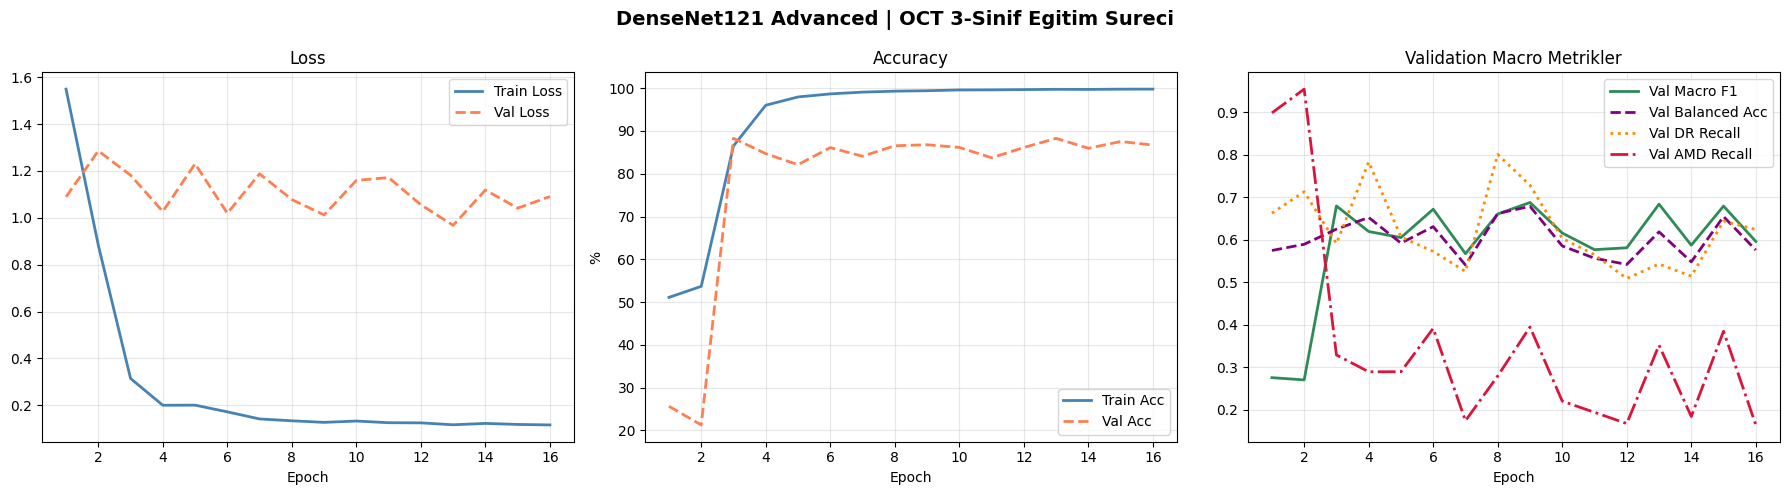

Egitim grafikleri kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_oct_3sinif_colab/densenet121_advanced_training_curves.png


In [8]:
# -- HUCRE 8: Egitim grafikleri ------------------------------------
hist = pd.DataFrame(history)
epochs_x = hist['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DenseNet121 Advanced | OCT 3-Sinif Egitim Sureci', fontsize=14, fontweight='bold')

axes[0].plot(epochs_x, hist['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_x, hist['val_loss'], label='Val Loss', color='coral', linestyle='--', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_x, hist['train_acc'] * 100, label='Train Acc', color='steelblue', linewidth=2)
axes[1].plot(epochs_x, hist['val_acc'] * 100, label='Val Acc', color='coral', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(epochs_x, hist['val_macro_f1'], label='Val Macro F1', color='seagreen', linewidth=2)
axes[2].plot(epochs_x, hist['val_bal_acc'], label='Val Balanced Acc', color='purple', linestyle='--', linewidth=2)
axes[2].plot(epochs_x, hist['val_dr_recall'], label='Val DR Recall', color='darkorange', linestyle=':', linewidth=2)
axes[2].plot(epochs_x, hist['val_amd_recall'], label='Val AMD Recall', color='crimson', linestyle='-.', linewidth=2)
axes[2].set_title('Validation Macro Metrikler')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
training_curve_path = SAVE_DIR / 'densenet121_advanced_training_curves.png'
plt.savefig(training_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print('Egitim grafikleri kaydedildi:', training_curve_path)


val_image_threshold:   0%|          | 0/456 [00:00<?, ?it/s]

Best image thresholds: {'dr_thr': 0.35, 'amd_thr': 0.39999999999999997, 'score': 0.8421126641389521, 'macro_f1': 0.66817260565942, 'balanced_acc': 0.6745248538011696, 'dr_recall': 0.8278508771929824, 'amd_recall': 0.29605263157894735}


val_patient_threshold:   0%|          | 0/456 [00:00<?, ?it/s]

Best patient thresholds: {'dr_thr': 0.3, 'amd_thr': 0.35, 'score': 1.152456140350877, 'macro_f1': 0.8991228070175438, 'balanced_acc': 0.9666666666666667, 'dr_recall': 1.0, 'amd_recall': 1.0}


test:   0%|          | 0/722 [00:00<?, ?it/s]

IMAGE-LEVEL TEST RAPORU | ARGMAX
              precision    recall  f1-score   support

      NORMAL     0.9638    0.9795    0.9716      9424
          DR     0.8892    0.8092    0.8473      1824
         AMD     0.9682    1.0000    0.9838       304

    accuracy                         0.9532     11552
   macro avg     0.9404    0.9296    0.9342     11552
weighted avg     0.9521    0.9532    0.9523     11552

Balanced Accuracy: 0.9296
Macro AUC OvR    : 0.9853

IMAGE-LEVEL TEST RAPORU | THRESHOLD
Thresholds: DR=0.35, AMD=0.40
              precision    recall  f1-score   support

      NORMAL     0.9660    0.9754    0.9706      9424
          DR     0.8781    0.8218    0.8491      1824
         AMD     0.9240    1.0000    0.9605       304

    accuracy                         0.9518     11552
   macro avg     0.9227    0.9324    0.9267     11552
weighted avg     0.9510    0.9518    0.9512     11552

Balanced Accuracy: 0.9324


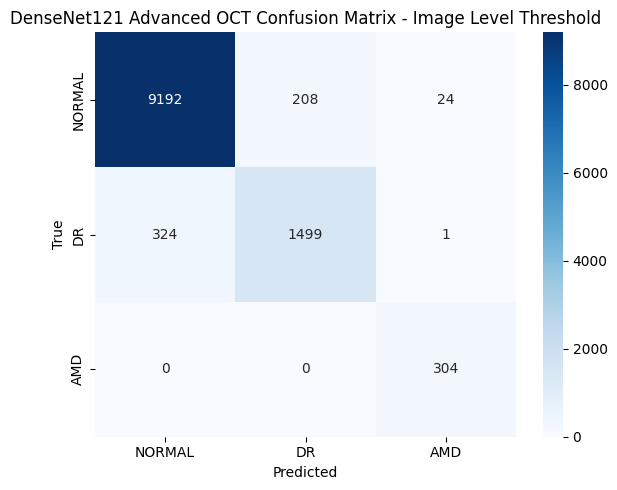

Image CM kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_oct_3sinif_colab/densenet121_advanced_oct_confusion_matrix_image.png


In [9]:
import torch

# -- HUCRE 9: Validasyon threshold secimi ve test tahminleri ---------
checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


def collect_probs(loader, desc):
    probs_all, labels_all, patients_all = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            if len(batch) == 3:
                images, labels, patient_ids = batch
                patients_all.extend(list(patient_ids))
            else:
                images, labels = batch
            images = images.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
            probs_all.append(probs.cpu().numpy())
            labels_all.extend(labels.numpy().tolist())
    probs_all = np.concatenate(probs_all, axis=0)
    labels_all = np.array(labels_all)
    return probs_all, labels_all, patients_all


def threshold_predict(probs, dr_thr=0.50, amd_thr=0.50):
    preds = []
    for p in probs:
        # AMD hasta sayisi cok az oldugu icin once AMD esigi kontrol edilir.
        if p[2] >= amd_thr:
            preds.append(2)
        elif p[1] >= dr_thr:
            preds.append(1)
        else:
            preds.append(int(np.argmax(p)))
    return np.array(preds)


def threshold_score(y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    dr_recall = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    amd_recall = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    return macro_f1 + 0.20 * bal_acc + 0.04 * dr_recall + 0.02 * amd_recall


def find_best_thresholds(y_true, probs):
    best = {'dr_thr': 0.50, 'amd_thr': 0.50, 'score': -1.0}
    for dr_thr in np.arange(0.25, 0.71, 0.05):
        for amd_thr in np.arange(0.20, 0.71, 0.05):
            preds = threshold_predict(probs, dr_thr=dr_thr, amd_thr=amd_thr)
            score = threshold_score(y_true, preds)
            if score > best['score']:
                best = {
                    'dr_thr': float(dr_thr),
                    'amd_thr': float(amd_thr),
                    'score': float(score),
                    'macro_f1': float(f1_score(y_true, preds, average='macro', zero_division=0)),
                    'balanced_acc': float(balanced_accuracy_score(y_true, preds)),
                    'dr_recall': float(recall_score(y_true, preds, labels=[1], average=None, zero_division=0)[0]),
                    'amd_recall': float(recall_score(y_true, preds, labels=[2], average=None, zero_division=0)[0]),
                }
    return best


def patient_frame_from_probs(frame, probs, labels, patient_ids):
    probs_df = frame.copy().reset_index(drop=True)
    probs_df['patient_id'] = list(patient_ids)
    probs_df['true'] = labels
    probs_df['p_normal'] = probs[:, 0]
    probs_df['p_dr'] = probs[:, 1]
    probs_df['p_amd'] = probs[:, 2]
    return (
        probs_df
        .groupby('patient_id')
        .agg({
            'true': 'first',
            'disease': 'first',
            'p_normal': 'mean',
            'p_dr': 'mean',
            'p_amd': 'mean',
            'img_path': 'count',
        })
        .rename(columns={'img_path': 'image_count'})
        .reset_index()
    )

val_probs, val_labels, _ = collect_probs(val_loader, desc='val_image_threshold')
image_thresholds = find_best_thresholds(val_labels, val_probs)
print('Best image thresholds:', image_thresholds)

val_patient_probs_raw, val_patient_labels_raw, val_patient_ids = collect_probs(val_patient_loader, desc='val_patient_threshold')
val_patient_df = patient_frame_from_probs(val_df, val_patient_probs_raw, val_patient_labels_raw, val_patient_ids)
val_patient_true = val_patient_df['true'].values
val_patient_probs = val_patient_df[['p_normal', 'p_dr', 'p_amd']].values
patient_thresholds = find_best_thresholds(val_patient_true, val_patient_probs)
print('Best patient thresholds:', patient_thresholds)

with open(SAVE_DIR / 'best_thresholds_densenet121_advanced_oct.json', 'w', encoding='utf-8') as f:
    json.dump({'image': image_thresholds, 'patient': patient_thresholds}, f, indent=2)

test_probs, test_labels, all_patients = collect_probs(test_loader, desc='test')
test_preds = test_probs.argmax(axis=1)
test_preds_thr = threshold_predict(
    test_probs,
    dr_thr=image_thresholds['dr_thr'],
    amd_thr=image_thresholds['amd_thr'],
)

print('IMAGE-LEVEL TEST RAPORU | ARGMAX')
print('=' * 70)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Balanced Accuracy: {balanced_accuracy_score(test_labels, test_preds):.4f}')
print(f'Macro AUC OvR    : {safe_macro_auc(test_labels, test_probs):.4f}')

print('\nIMAGE-LEVEL TEST RAPORU | THRESHOLD')
print('=' * 70)
print(f"Thresholds: DR={image_thresholds['dr_thr']:.2f}, AMD={image_thresholds['amd_thr']:.2f}")
print(classification_report(test_labels, test_preds_thr, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Balanced Accuracy: {balanced_accuracy_score(test_labels, test_preds_thr):.4f}')

cm_img = confusion_matrix(test_labels, test_preds_thr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_img, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('DenseNet121 Advanced OCT Confusion Matrix - Image Level Threshold')
plt.tight_layout()
image_cm_path = SAVE_DIR / 'densenet121_advanced_oct_confusion_matrix_image.png'
plt.savefig(image_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print('Image CM kaydedildi:', image_cm_path)


PATIENT-LEVEL TEST RAPORU | ARGMAX
              precision    recall  f1-score   support

      NORMAL     1.0000    1.0000    1.0000        31
          DR     1.0000    1.0000    1.0000         6
         AMD     1.0000    1.0000    1.0000         1

    accuracy                         1.0000        38
   macro avg     1.0000    1.0000    1.0000        38
weighted avg     1.0000    1.0000    1.0000        38

Patient Balanced Accuracy: 1.0000

PATIENT-LEVEL TEST RAPORU | THRESHOLD
Thresholds: DR=0.30, AMD=0.35
              precision    recall  f1-score   support

      NORMAL     1.0000    0.9677    0.9836        31
          DR     0.8571    1.0000    0.9231         6
         AMD     1.0000    1.0000    1.0000         1

    accuracy                         0.9737        38
   macro avg     0.9524    0.9892    0.9689        38
weighted avg     0.9774    0.9737    0.9745        38

Patient Balanced Accuracy: 0.9892


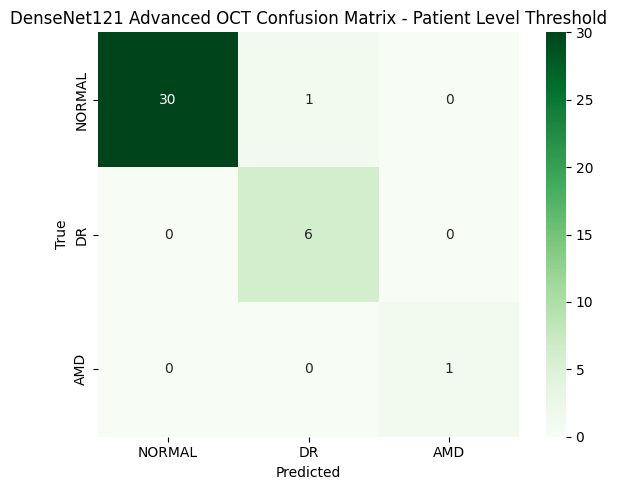

Patient CM kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_oct_3sinif_colab/densenet121_advanced_oct_confusion_matrix_patient.png


In [10]:
# -- HUCRE 10: Patient-level degerlendirme --------------------------
patient_df = patient_frame_from_probs(test_df, test_probs, test_labels, all_patients)

patient_true = patient_df['true'].values
patient_probs = patient_df[['p_normal', 'p_dr', 'p_amd']].values
patient_preds = patient_probs.argmax(axis=1)
patient_preds_thr = threshold_predict(
    patient_probs,
    dr_thr=patient_thresholds['dr_thr'],
    amd_thr=patient_thresholds['amd_thr'],
)

patient_df['pred_argmax'] = [CLASS_NAMES[idx] for idx in patient_preds]
patient_df['pred_threshold'] = [CLASS_NAMES[idx] for idx in patient_preds_thr]
patient_df.to_csv(SAVE_DIR / 'densenet121_advanced_oct_patient_predictions.csv', index=False)

print('PATIENT-LEVEL TEST RAPORU | ARGMAX')
print('=' * 70)
print(classification_report(patient_true, patient_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Patient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds):.4f}')

print('\nPATIENT-LEVEL TEST RAPORU | THRESHOLD')
print('=' * 70)
print(f"Thresholds: DR={patient_thresholds['dr_thr']:.2f}, AMD={patient_thresholds['amd_thr']:.2f}")
print(classification_report(patient_true, patient_preds_thr, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Patient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds_thr):.4f}')

cm_patient = confusion_matrix(patient_true, patient_preds_thr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('DenseNet121 Advanced OCT Confusion Matrix - Patient Level Threshold')
plt.tight_layout()
patient_cm_path = SAVE_DIR / 'densenet121_advanced_oct_confusion_matrix_patient.png'
plt.savefig(patient_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print('Patient CM kaydedildi:', patient_cm_path)


In [11]:
# -- HUCRE 11: Metrik tablosu ve rapor dosyasi -----------------------
metrics_summary = pd.DataFrame(
    [
        summarize_metrics(test_labels, test_preds, test_probs, level='image', decision='argmax'),
        summarize_metrics(test_labels, test_preds_thr, test_probs, level='image', decision='threshold'),
        summarize_metrics(patient_true, patient_preds, patient_probs, level='patient', decision='mean_argmax'),
        summarize_metrics(patient_true, patient_preds_thr, patient_probs, level='patient', decision='mean_threshold'),
    ]
)
preferred_cols = [
    'level',
    'decision',
    'accuracy',
    'balanced_accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'macro_auc_ovr',
    'normal_recall',
    'dr_recall',
    'amd_recall',
    'normal_f1',
    'dr_f1',
    'amd_f1',
]
metrics_summary = metrics_summary[[col for col in preferred_cols if col in metrics_summary.columns]]
metrics_path = SAVE_DIR / 'metrics_summary.csv'
metrics_summary.to_csv(metrics_path, index=False)

report_path = SAVE_DIR / 'test_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('DenseNet121 Advanced | OCT 3-Sinif | Final Colab\n')
    f.write('=' * 70 + '\n\n')
    f.write(f'Toplam goruntulu hasta: {img_df["patient_id"].nunique()} / {df["patient_id"].nunique()}\n')
    f.write(f'Eksik OCT hasta klasoru: {missing}\n')
    f.write(f'Image thresholds: {image_thresholds}\n')
    f.write(f'Patient thresholds: {patient_thresholds}\n\n')
    f.write('IMAGE-LEVEL REPORT | ARGMAX\n')
    f.write(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nBalanced Accuracy: {balanced_accuracy_score(test_labels, test_preds):.4f}\n')
    f.write(f'Macro AUC OvR    : {safe_macro_auc(test_labels, test_probs):.4f}\n\n')
    f.write('IMAGE-LEVEL REPORT | THRESHOLD\n')
    f.write(classification_report(test_labels, test_preds_thr, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nBalanced Accuracy: {balanced_accuracy_score(test_labels, test_preds_thr):.4f}\n\n')
    f.write('PATIENT-LEVEL REPORT | ARGMAX\n')
    f.write(classification_report(patient_true, patient_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nPatient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds):.4f}\n\n')
    f.write('PATIENT-LEVEL REPORT | THRESHOLD\n')
    f.write(classification_report(patient_true, patient_preds_thr, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nPatient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds_thr):.4f}\n\n')
    f.write('IMAGE CM | THRESHOLD\n')
    f.write(np.array2string(cm_img) + '\n\n')
    f.write('PATIENT CM | THRESHOLD\n')
    f.write(np.array2string(cm_patient) + '\n')

print('Metrik tablosu kaydedildi:', metrics_path)
print('Rapor kaydedildi:', report_path)
display(metrics_summary.round(4))


Metrik tablosu kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_oct_3sinif_colab/metrics_summary.csv
Rapor kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_oct_3sinif_colab/test_report.txt


,level,decision,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,macro_auc_ovr,normal_recall,dr_recall,amd_recall,normal_f1,dr_f1,amd_f1
0,image,argmax,0.9532,0.9296,0.9404,0.9296,0.9342,0.9853,0.9795,0.8092,1.0,0.9716,0.8473,0.9838
1,image,threshold,0.9518,0.9324,0.9227,0.9324,0.9267,0.9853,0.9754,0.8218,1.0,0.9706,0.8491,0.9605
2,patient,mean_argmax,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,1.0000
3,patient,mean_threshold,0.9737,0.9892,0.9524,0.9892,0.9689,1.0000,0.9677,1.0000,1.0,0.9836,0.9231,1.0000


## Not

Bu notebook mevcut DenseNet121 deneyinin daha agresif final Colab surumudur. Ana rapor icin hasta bazli Macro-F1 ve Balanced Accuracy oncelikli okunmalidir. AMD test hasta sayisi dusuk oldugu icin AMD hasta-bazli recall sonucu raporda bu sinirla birlikte yorumlanmalidir.
